In [7]:
import os
import numpy as np
from PIL import Image
import shutil
import random
import re

# Set a random seed so your 1:1 sampling is reproducible if you run it again
random.seed(42)

# Directories
base_path = r'c:\Users\roshni\Documents\BTech_Major_Project\dataset_2\val'
png_root = r'c:\Users\roshni\Documents\BTech_Major_Project\png_outputs_val'
npy_root = r'c:\Users\roshni\Documents\BTech_Major_Project\npy_filtered_val'

def convert_normalized_to_png(arr):
    if arr.max() <= 1.0:
        arr = arr * 255
    return np.clip(arr, 0, 255).astype(np.uint8)

# Helper function to sort files numerically (e.g., 2.npy comes before 10.npy)
def numeric_sort_key(filename):
    numbers = re.findall(r'\d+', filename)
    return int(numbers[0]) if numbers else 0

for dir_name in os.listdir(base_path):
    dir_path = os.path.join(base_path, dir_name)
    if not os.path.isdir(dir_path):
        continue

    data_path = os.path.join(dir_path, 'data')
    masks_path = os.path.join(dir_path, 'masks')

    # Setup PNG output paths
    out_png_data = os.path.join(png_root, dir_name, 'data')
    out_png_masks = os.path.join(png_root, dir_name, 'masks')
    os.makedirs(out_png_data, exist_ok=True)
    os.makedirs(out_png_masks, exist_ok=True)

    # Setup NPY output paths
    out_npy_data = os.path.join(npy_root, dir_name, 'data')
    out_npy_masks = os.path.join(npy_root, dir_name, 'masks')
    os.makedirs(out_npy_data, exist_ok=True)
    os.makedirs(out_npy_masks, exist_ok=True)

    # 1. Get all mask files and sort them numerically
    all_mask_files = [f for f in os.listdir(masks_path) if f.endswith('.npy')]
    all_mask_files.sort(key=numeric_sort_key)

    # 2. Skip the first 50 slices (Abdomen region)
    valid_files = all_mask_files[50:]
    
    tumor_files = []
    non_tumor_files = []

    # 3. Categorize the remaining slices into tumor and non-tumor
    for fname in valid_files:
        mask_arr = np.load(os.path.join(masks_path, fname))
        if mask_arr.max() > 0:
            tumor_files.append(fname)
        else:
            non_tumor_files.append(fname)

    # 4. Enforce the 1:1 Ratio
    num_tumors = len(tumor_files)
    if num_tumors == 0:
        print(f"Skipping {dir_name}: No tumors found after dropping first 50 slices.")
        continue
    
    # Randomly sample non-tumor files to match the number of tumor files
    sampled_non_tumors = random.sample(
        non_tumor_files, 
        min(num_tumors, len(non_tumor_files)) # Prevents errors if there are fewer empty masks than tumors
    )

    # Combine both lists for final processing
    files_to_process = tumor_files + sampled_non_tumors

    # 5. Process and Save the Filtered Files
    for fname in files_to_process:
        src_data_file = os.path.join(data_path, fname)
        src_mask_file = os.path.join(masks_path, fname)

        if not os.path.exists(src_data_file):
            continue

        # --- SAVE AS NPY (Copying is faster and preserves original data exactly) ---
        shutil.copy(src_data_file, os.path.join(out_npy_data, fname))
        shutil.copy(src_mask_file, os.path.join(out_npy_masks, fname))

        # --- SAVE AS PNG ---
        data_arr = np.load(src_data_file)
        mask_arr = np.load(src_mask_file)
        
        png_data = convert_normalized_to_png(data_arr)
        png_mask = convert_normalized_to_png(mask_arr)
        
        Image.fromarray(png_data).save(os.path.join(out_png_data, fname.replace('.npy', '.png')))
        Image.fromarray(png_mask).save(os.path.join(out_png_masks, fname.replace('.npy', '.png')))

    print(f"Processed {dir_name}: Saved {num_tumors} tumor slices and {len(sampled_non_tumors)} non-tumor slices.")

print("All done! Filtered NPY and PNG datasets created successfully.")

Processed 57: Saved 18 tumor slices and 18 non-tumor slices.
Processed 58: Saved 35 tumor slices and 35 non-tumor slices.
Processed 59: Saved 16 tumor slices and 16 non-tumor slices.
Processed 60: Saved 5 tumor slices and 5 non-tumor slices.
Processed 61: Saved 12 tumor slices and 12 non-tumor slices.
Processed 62: Saved 11 tumor slices and 11 non-tumor slices.
All done! Filtered NPY and PNG datasets created successfully.


--- Array Statistics for 369.npy ---
Data Type: float16
Minimum Value: 0.0
Maximum Value: 0.6904296875
Mean Value: 0.0929


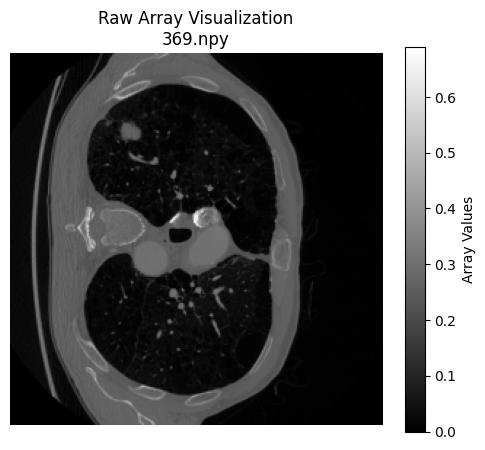

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_path = r'c:\Users\roshni\Documents\BTech_Major_Project\dataset_2\train'

# Find the first directory
dir_names = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
test_dir = os.path.join(base_path, dir_names[0])
data_path = os.path.join(test_dir, 'data')

# Find the first .npy file
test_file = [f for f in os.listdir(data_path) if f.endswith('.npy')][300]
file_path = os.path.join(data_path, test_file)

# Load the raw array
arr = np.load(file_path)

# Print the vital statistics
print(f"--- Array Statistics for {test_file} ---")
print(f"Data Type: {arr.dtype}")
print(f"Minimum Value: {arr.min()}")
print(f"Maximum Value: {arr.max()}")
print(f"Mean Value: {arr.mean():.4f}")

# Plot the raw array with a colorbar to see the actual scale
plt.figure(figsize=(6, 5))
plt.imshow(arr, cmap='gray')
plt.colorbar(label='Array Values')
plt.title(f"Raw Array Visualization\n{test_file}")
plt.axis('off')
plt.show()